In [1]:
# 🚀 Load Data for Model Building
# Load meteorological data (X features) and 2D wave spectra (Y targets)

import pandas as pd
import numpy as np
from pathlib import Path
import pickle
import warnings
warnings.filterwarnings('ignore')

print("🚀 Loading data for model building...")

# =============================================================================
# 📊 Load Meteorological DataFrames (X Features)
# =============================================================================

print("\n📊 Loading meteorological dataframes...")

# Define dataframes directory path
dataframes_dir = Path('../data/dataframes')

if not dataframes_dir.exists():
    print(f"❌ Directory not found: {dataframes_dir}")
    print("   Make sure to run the data engineering pipeline first!")
else:
    print(f"📁 Loading from: {dataframes_dir.absolute()}")
    
    # Find all met pickle files
    met_pkl_files = list(dataframes_dir.glob("met_*.pkl"))
    
    if not met_pkl_files:
        print("❌ No meteorological pickle files found!")
    else:
        print(f"🎯 Found {len(met_pkl_files)} meteorological files")
        
        # Load each met dataframe
        loaded_met_count = 0
        failed_met_count = 0
        met_size_mb = 0
        loaded_met_dfs = []
        
        for pkl_file in sorted(met_pkl_files):
            try:
                # Extract dataframe name from filename
                df_name = pkl_file.stem
                
                # Load dataframe from pickle
                df = pd.read_pickle(pkl_file)
                
                # Create variable in global namespace
                globals()[df_name] = df
                
                # Get file size
                file_size_mb = pkl_file.stat().st_size / (1024 * 1024)
                met_size_mb += file_size_mb
                
                loaded_met_count += 1
                loaded_met_dfs.append(df_name)
                
                print(f"  ✅ {df_name}: {df.shape} ({file_size_mb:.2f} MB)")
                
            except Exception as e:
                failed_met_count += 1
                print(f"  ❌ {pkl_file.name}: Error - {str(e)}")
        
        print(f"\n✅ Meteorological data loading completed!")
        print(f"   ✅ Successfully loaded: {loaded_met_count}")
        print(f"   ❌ Failed to load: {failed_met_count}")
        print(f"   💽 Total size: {met_size_mb:.2f} MB")

# =============================================================================
# 🌊 Load 2D Wave Spectrum Y DataFrames (Y Targets)
# =============================================================================

print("\n🌊 Loading 2D wave spectrum Y variables...")

# Check Y spectra directory
y_spectra_dir = Path('../data/Y_spectra')

if not y_spectra_dir.exists():
    print(f"❌ Y spectra directory not found: {y_spectra_dir}")
    print("   Run Y_prep.ipynb first to create 2D wave spectra!")
else:
    print(f"📁 Loading from: {y_spectra_dir.absolute()}")
    
    # Find all Y pickle files
    y_pkl_files = list(y_spectra_dir.glob("Y_*.pkl"))
    
    if not y_pkl_files:
        print("❌ No Y spectrum pickle files found!")
    else:
        print(f"🎯 Found {len(y_pkl_files)} Y spectrum files")
        
        # Load each Y variable
        loaded_y_count = 0
        failed_y_count = 0
        y_size_mb = 0
        loaded_y_dfs = []
        
        for pkl_file in sorted(y_pkl_files):
            try:
                # Extract variable name from filename
                y_name = pkl_file.stem  # Remove .pkl extension
                
                # Load DataFrame
                y_df = pd.read_pickle(pkl_file)
                
                # Store in global namespace
                globals()[y_name] = y_df
                
                # Get file size
                file_size_mb = pkl_file.stat().st_size / (1024 * 1024)
                y_size_mb += file_size_mb
                
                loaded_y_dfs.append(y_name)
                loaded_y_count += 1
                
                print(f"  ✅ {y_name}: {y_df.shape} ({file_size_mb:.2f} MB)")
                
            except Exception as e:
                failed_y_count += 1
                print(f"  ❌ {pkl_file.name}: Error - {str(e)}")
        
        print(f"\n✅ Y spectrum data loading completed!")
        print(f"   ✅ Successfully loaded: {loaded_y_count}")
        print(f"   ❌ Failed to load: {failed_y_count}")
        print(f"   💽 Total size: {y_size_mb:.2f} MB")

print("\n✅ All data loaded successfully! Ready for model building.")

🚀 Loading data for model building...

📊 Loading meteorological dataframes...
📁 Loading from: d:\projects\FYP-OCNWVS\notebooks\..\data\dataframes
🎯 Found 21 meteorological files
  ✅ met_41008_2006: (739, 7) (0.04 MB)
  ✅ met_41008_2007: (8650, 7) (0.50 MB)
  ✅ met_41008_2008: (8650, 7) (0.50 MB)
  ✅ met_41008_2009: (3250, 7) (0.19 MB)
  ✅ met_41008_2013: (8041, 7) (0.47 MB)
  ✅ met_41008_2014: (8406, 7) (0.49 MB)
  ✅ met_41008_2015: (8644, 7) (0.50 MB)
  ✅ met_41008_2016: (6151, 7) (0.36 MB)
  ✅ met_41008_2017: (8583, 7) (0.50 MB)
  ✅ met_41008_2018: (8613, 7) (0.50 MB)
  ✅ met_41008_2019: (8586, 7) (0.50 MB)
  ✅ met_41008_2020: (8580, 7) (0.50 MB)
  ✅ met_41008_2021: (8490, 7) (0.49 MB)
  ✅ met_41008_2022: (8655, 7) (0.50 MB)
  ✅ met_41008_2023: (5322, 7) (0.31 MB)
  ✅ met_41008_2024: (1825, 7) (0.11 MB)
  ✅ met_41008_2025: (1791, 7) (0.10 MB)
  ✅ met_51028_2005: (6787, 7) (0.40 MB)
  ✅ met_51028_2006: (7073, 7) (0.41 MB)
  ✅ met_51028_2007: (2962, 7) (0.17 MB)
  ✅ met_51028_2008: (250

In [2]:
# 🔧 Process X Features (Meteorological Data)
# Convert directional variables to sin/cos and standardize

from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

print("🔧 Processing X features (meteorological data)...")

# =============================================================================
# 🔄 Process All Meteorological DataFrames  
# =============================================================================

# Find all met variables
met_variables = [name for name in globals().keys() if name.startswith('met_') and isinstance(globals()[name], pd.DataFrame)]

if not met_variables:
    print("❌ No meteorological dataframes found!")
else:
    print(f"\n🎯 Processing {len(met_variables)} meteorological datasets...")
    
    # Storage for processed data
    X_processed = {}
    feature_names = None
    
    # Process all datasets (convert directions, handle missing) WITHOUT scaling
    print(f"\n📊 Converting directions and handling missing values...")
    
    for met_name in sorted(met_variables):
        print(f"  📍 Processing {met_name}...")
        
        met_df = globals()[met_name]
        
        # Create copy to avoid modifying original
        df = met_df.copy()
        
        # Remove timekey column
        if 'timekey' in df.columns:
            df = df.drop('timekey', axis=1)
        
        print(f"    Original columns: {list(df.columns)}")
        
        # Convert directional variables to sin/cos
        directional_cols = ['WDIR', 'MWD']  # Wind direction, Mean Wave Direction
        
        for col in directional_cols:
            if col in df.columns:
                # Convert degrees to radians
                angles_rad = np.deg2rad(df[col])
                
                # Create sin/cos components
                df[f'{col}_sin'] = np.sin(angles_rad)
                df[f'{col}_cos'] = np.cos(angles_rad)
                
                # Drop original angle column
                df = df.drop(col, axis=1)
                print(f"    ✅ Converted {col} → {col}_sin, {col}_cos")
        
        # Expected final columns: [WSPD, WVHT, DPD, APD, WDIR_sin, WDIR_cos, MWD_sin, MWD_cos]
        final_cols = list(df.columns)
        print(f"    Final columns ({len(final_cols)}): {final_cols}")
        
        # Get feature names (should be same for all datasets)
        if feature_names is None:
            feature_names = final_cols
        
        # Convert to numpy array (unscaled)
        X_unscaled = df.values
        
        # Store UNSCALED processed data
        X_processed[met_name] = X_unscaled
        
        print(f"    ✅ Processed shape: {X_unscaled.shape} (UNSCALED)")
    
    print(f"\n✅ Meteorological data processing completed!")
    print(f"   📊 Processed datasets: {len(X_processed)}")
    print(f"   🔧 Feature names: {feature_names}")
    print(f"   📏 Data is UNSCALED - scaling will be done after train-test split")
    
    # Show summary by station
    stations = {}
    for met_name in X_processed.keys():
        parts = met_name.split('_')
        if len(parts) >= 3:
            station = parts[1]
            year = parts[2]
            if station not in stations:
                stations[station] = []
            stations[station].append((year, X_processed[met_name].shape))
    
    print(f"\n📍 X Features by Station:")
    for station, data in sorted(stations.items()):
        years = [item[0] for item in data]
        total_samples = sum(item[1][0] for item in data)
        n_features = data[0][1][1] if data else 0
        print(f"   Station {station}: {len(data)} years ({', '.join(sorted(years))}) - {total_samples:,} samples × {n_features} features")

print(f"\n🎯 X features ready for alignment and train-test split!")
print(f"📋 Expected 8 features: [WSPD, WVHT, DPD, APD, WDIR_sin, WDIR_cos, MWD_sin, MWD_cos]")

print(f"\n🎯 X features ready for model training!")

🔧 Processing X features (meteorological data)...

🎯 Processing 21 meteorological datasets...

📊 Converting directions and handling missing values...
  📍 Processing met_41008_2006...
    Original columns: ['WDIR', 'WSPD', 'WVHT', 'DPD', 'APD', 'MWD']
    ✅ Converted WDIR → WDIR_sin, WDIR_cos
    ✅ Converted MWD → MWD_sin, MWD_cos
    Final columns (8): ['WSPD', 'WVHT', 'DPD', 'APD', 'WDIR_sin', 'WDIR_cos', 'MWD_sin', 'MWD_cos']
    ✅ Processed shape: (739, 8) (UNSCALED)
  📍 Processing met_41008_2007...
    Original columns: ['WDIR', 'WSPD', 'WVHT', 'DPD', 'APD', 'MWD']
    ✅ Converted WDIR → WDIR_sin, WDIR_cos
    ✅ Converted MWD → MWD_sin, MWD_cos
    Final columns (8): ['WSPD', 'WVHT', 'DPD', 'APD', 'WDIR_sin', 'WDIR_cos', 'MWD_sin', 'MWD_cos']
    ✅ Processed shape: (8650, 8) (UNSCALED)
  📍 Processing met_41008_2008...
    Original columns: ['WDIR', 'WSPD', 'WVHT', 'DPD', 'APD', 'MWD']
    ✅ Converted WDIR → WDIR_sin, WDIR_cos
    ✅ Converted MWD → MWD_sin, MWD_cos
    Final columns 

In [3]:
# 🌊 Process Y Targets (2D Wave Spectrum Data)
# Apply log transform: Y → log(Y+ε)

import pandas as pd
import numpy as np

print("🌊 Processing Y targets (2D wave spectrum data)...")

# =============================================================================
# 📊 Log Transform Parameters 
# =============================================================================

# Small epsilon to avoid log(0)
epsilon = 1e-6

print(f"🔬 Transform pipeline: Y → log(Y + ε), where ε = {epsilon}")

# =============================================================================
# 🔄 Process All Y DataFrames
# =============================================================================

# Find all Y variables
y_variables = [name for name in globals().keys() if name.startswith('Y_') and isinstance(globals()[name], pd.DataFrame)]

if not y_variables:
    print("❌ No Y dataframes found!")
else:
    print(f"\n🎯 Processing {len(y_variables)} Y spectrum datasets...")
    
    # Storage for processed data  
    Y_processed = {}
    Y_timekeys = {}
    Y_means = {}  # Store means for denormalization
    Y_stds = {}   # Store std for denormalization
    spectrum_columns = None
    
    # Process each Y dataframe
    for y_name in sorted(y_variables):
        print(f"\n📍 Processing {y_name}...")
        
        y_df = globals()[y_name]
        
        print(f"  Original shape: {y_df.shape}")
        
        # Extract timekey for alignment with X data
        if 'timekey' in y_df.columns:
            timekeys = y_df['timekey'].values
            # Remove timekey column for spectrum processing
            spectrum_df = y_df.drop('timekey', axis=1)
        else:
            print("  ⚠️ No timekey column found!")
            timekeys = None
            spectrum_df = y_df.copy()
        
        # Get spectrum column names
        if spectrum_columns is None:
            spectrum_columns = list(spectrum_df.columns)
            
        print(f"  Spectrum shape: {spectrum_df.shape}")
        print(f"  Spectrum columns: {len(spectrum_columns)} (f×θ combinations)")
        print(f"  Sample columns: {spectrum_columns[:5]}...")
        
        # Convert to numpy array Y.shape → (time, 1692)
        Y = spectrum_df.values
        
        # Check for negative values (should not exist in energy spectra)
        negative_count = (Y < 0).sum()
        if negative_count > 0:
            print(f"  ⚠️ Found {negative_count} negative values - setting to zero")
            Y = np.maximum(Y, 0)
        
        # Check data statistics before transform
        zero_count = (Y == 0).sum()
        total_count = Y.size
        nonzero_min = Y[Y > 0].min() if (Y > 0).any() else 0
        
        print(f"  📊 Pre-transform stats:")
        print(f"     Zero values: {zero_count:,}/{total_count:,} ({100*zero_count/total_count:.1f}%)")
        print(f"     Non-zero min: {nonzero_min:.2e}")
        print(f"     Max value: {Y.max():.2e}")
        
        # Apply log transform: Y_log = log(Y + ε)
        Y_log = np.log(Y + epsilon)
        
        print(f"  🔬 Log-transform stats:")
        print(f"     Min: {Y_log.min():.6f}")
        print(f"     Max: {Y_log.max():.6f}")
        print(f"     Mean: {Y_log.mean():.6f}")
        print(f"     Std: {Y_log.std():.6f}")
        
        # Store log-transformed data (NO standardization)
        Y_processed[y_name] = Y_log
        Y_timekeys[y_name] = timekeys
        
        print(f"  ✅ Y_log ready: {Y_log.shape}")
    
    print(f"\n✅ Y spectrum data processing completed!")
    print(f"   📊 Processed datasets: {len(Y_processed)}")
    print(f"   🔬 Transform: Y → log(Y + {epsilon}) ONLY")
    print(f"   📋 Spectrum features: {len(spectrum_columns) if spectrum_columns else 0}")
    print(f"   📊 Y_log values in natural log scale")
    
    # Show summary by station
    stations = {}
    for y_name in Y_processed.keys():
        parts = y_name.split('_')
        if len(parts) >= 3:
            station = parts[1]
            year = parts[2]
            if station not in stations:
                stations[station] = []
            stations[station].append((year, Y_processed[y_name].shape))
    
    print(f"\n📍 Y Targets by Station:")
    for station, data in sorted(stations.items()):
        years = [item[0] for item in data]
        total_samples = sum(item[1][0] for item in data)
        n_features = data[0][1][1] if data else 0
        print(f"   Station {station}: {len(data)} years ({', '.join(sorted(years))}) - {total_samples:,} samples × {n_features} features")

print(f"\n🎯 Y_norm arrays ready for train-test split!")
print(f"   Expected usage: Y_train = Y_norm[train_indices], Y_test = Y_norm[test_indices]")
print(f"   Y statistics (Y_means, Y_stds) stored for denormalization during evaluation")

🌊 Processing Y targets (2D wave spectrum data)...
🔬 Transform pipeline: Y → log(Y + ε), where ε = 1e-06

🎯 Processing 21 Y spectrum datasets...

📍 Processing Y_41008_2006...
  Original shape: (739, 1693)
  Spectrum shape: (739, 1692)
  Spectrum columns: 1692 (f×θ combinations)
  Sample columns: ['f.0200_dir000', 'f.0200_dir010', 'f.0200_dir020', 'f.0200_dir030', 'f.0200_dir040']...
  📊 Pre-transform stats:
     Zero values: 575,848/1,250,388 (46.1%)
     Non-zero min: 5.38e-11
     Max value: 5.57e-01
  🔬 Log-transform stats:
     Min: -13.815511
     Max: -0.585838
     Mean: -9.694050
     Std: 4.058849
  ✅ Y_log ready: (739, 1692)

📍 Processing Y_41008_2007...
  Original shape: (8650, 1693)
  Spectrum shape: (8650, 1692)
  Spectrum columns: 1692 (f×θ combinations)
  Sample columns: ['f.0200_dir000', 'f.0200_dir010', 'f.0200_dir020', 'f.0200_dir030', 'f.0200_dir040']...
  📊 Pre-transform stats:
     Zero values: 6,733,836/14,635,800 (46.0%)
     Non-zero min: 4.60e-20
     Max value:

In [4]:
# 🔗 Align X and Y Data + Train-Test Split for PINN
# Prepare data for Physics-Informed Neural Network approach

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

print("🔗 Preparing data for Physics-Informed Neural Network...")

# =============================================================================
# 📊 Extract Frequency and Direction Grids for Physics Calculations
# =============================================================================

def extract_frequency_direction_grids():
    """
    Extract frequency and direction grids from spectrum column names
    Returns frequency array (Hz) and direction array (degrees)
    """
    if spectrum_columns is None:
        print("❌ Spectrum columns not found!")
        return None, None
    
    # Parse column names like 'f.0200_dir000', 'f.0200_dir010', etc.
    frequencies = []
    directions = []
    
    for col in spectrum_columns:
        try:
            # Split by underscore: ['f.0200', 'dir000']
            parts = col.split('_')
            if len(parts) == 2:
                # Extract frequency: 'f.0200' → 0.0200 Hz
                freq_str = parts[0].replace('f.', '')
                freq_hz = float(freq_str) / 100.0  # Convert from 0200 to 0.02 Hz
                
                # Extract direction: 'dir000' → 0 degrees
                dir_str = parts[1].replace('dir', '')
                dir_deg = float(dir_str)
                
                if freq_hz not in frequencies:
                    frequencies.append(freq_hz)
                if dir_deg not in directions:
                    directions.append(dir_deg)
        except:
            continue
    
    frequencies = sorted(frequencies)
    directions = sorted(directions)
    
    print(f"   📊 Frequency grid: {len(frequencies)} bins, {frequencies[0]:.3f} to {frequencies[-1]:.3f} Hz")
    print(f"   🧭 Direction grid: {len(directions)} bins, {directions[0]:.0f} to {directions[-1]:.0f} degrees")
    
    return np.array(frequencies), np.array(directions)

# =============================================================================
# 🔗 Align X and Y Data by Timekey
# =============================================================================

def align_x_y_data_for_pinn():
    """
    Align processed X and Y data, extract bulk parameters for physics losses
    
    Returns:
        X_combined: Aligned X features, shape (n_samples, n_features)
        Y_combined: Aligned Y targets, shape (n_samples, n_spectrum_bins)
        bulk_params: Dict with Hs, DPD, APD, MWD for physics losses
        alignment_info: Information about successful alignments
    """
    
    print(f"\n🔗 Aligning X and Y datasets for PINN...")
    
    # Initialize containers
    X_aligned_list = []
    Y_aligned_list = []
    bulk_params_list = []
    alignment_info = []
    
    # Get all station-year combinations from X_processed
    x_keys = list(X_processed.keys())
    
    for x_key in sorted(x_keys):
        # Extract station and year from met key (e.g., "met_41008_2006")
        parts = x_key.split('_')
        if len(parts) >= 3:
            station = parts[1]
            year = parts[2]
            
            # Find corresponding Y key
            y_key = f"Y_{station}_{year}"
            
            if y_key in Y_processed and y_key in Y_timekeys:
                print(f"  📍 Aligning {x_key} ↔ {y_key}...")
                
                # Get processed arrays
                X_data = X_processed[x_key]  # [n_samples, n_features]
                Y_data = Y_processed[y_key]  # [n_samples, n_spectrum_bins]
                
                # Get timekeys from original dataframes
                # X timekeys: get from original met dataframe
                met_df_name = x_key  # e.g., "met_41008_2006"
                if met_df_name in globals():
                    met_df = globals()[met_df_name]
                    X_times = met_df['timekey'].values
                else:
                    print(f"    ❌ Original dataframe {met_df_name} not found")
                    continue
                
                # Y timekeys: get from Y_timekeys
                Y_times = Y_timekeys[y_key]  # timekeys
                
                # Create merged dataframe for alignment
                X_col_names = [f'X_{i}' for i in range(X_data.shape[1])]
                Y_col_names = [f'Y_{i}' for i in range(Y_data.shape[1])]
                
                X_df = pd.DataFrame(X_data, columns=X_col_names)
                X_df['timekey'] = X_times
                
                Y_df = pd.DataFrame(Y_data, columns=Y_col_names)
                Y_df['timekey'] = Y_times
                
                # Add bulk parameters from original met dataframe for physics losses
                bulk_df = met_df[['timekey', 'WVHT', 'DPD', 'APD', 'MWD']].copy()
                
                # Merge all together
                merged = pd.merge(X_df, Y_df, on='timekey')
                merged = pd.merge(merged, bulk_df, on='timekey')
                
                if len(merged) == 0:
                    print(f"    ❌ No common timekeys found")
                    continue
                
                # Extract aligned arrays
                X_cols = [col for col in merged.columns if col.startswith('X_')]
                Y_cols = [col for col in merged.columns if col.startswith('Y_')]
                bulk_cols = ['WVHT', 'DPD', 'APD', 'MWD']
                
                X_aligned = merged[X_cols].values
                Y_aligned = merged[Y_cols].values
                bulk_aligned = merged[bulk_cols].values
                
                # Store aligned data
                X_aligned_list.append(X_aligned)
                Y_aligned_list.append(Y_aligned)
                bulk_params_list.append(bulk_aligned)
                
                alignment_info.append({
                    'x_key': x_key,
                    'y_key': y_key,
                    'station': station,
                    'year': year,
                    'x_original': len(X_data),
                    'y_original': len(Y_data),
                    'aligned': len(X_aligned),
                    'x_shape': X_aligned.shape,
                    'y_shape': Y_aligned.shape
                })
                
                print(f"    ✅ Aligned {len(X_aligned):,} samples ({X_aligned.shape[1]} X features, {Y_aligned.shape[1]} Y features)")
            else:
                print(f"    ❌ Missing Y data for {y_key}")
    
    if not X_aligned_list:
        print("❌ No data could be aligned!")
        return None, None, None, []
        
    # Concatenate all aligned datasets
    X_combined = np.vstack(X_aligned_list)
    Y_combined = np.vstack(Y_aligned_list)
    bulk_params_combined = np.vstack(bulk_params_list)
    
    # Organize bulk parameters dictionary
    bulk_params = {
        'Hs': bulk_params_combined[:, 0],  # WVHT ≈ Hs
        'DPD': bulk_params_combined[:, 1],  # Dominant Period
        'APD': bulk_params_combined[:, 2],  # Average Period  
        'MWD': bulk_params_combined[:, 3]   # Mean Wave Direction
    }
    
    print(f"\n✅ Data alignment for PINN completed!")
    print(f"   📊 Combined X shape: {X_combined.shape}")
    print(f"   📊 Combined Y shape: {Y_combined.shape}")
    print(f"   🌊 Bulk parameters for physics losses: Hs, DPD, APD, MWD")
    print(f"   🔗 Successful alignments: {len(alignment_info)}")
    
    return X_combined, Y_combined, bulk_params, alignment_info

# =============================================================================
# 🔄 Execute Alignment and Setup
# =============================================================================

# Check if processed data exists
if 'X_processed' not in globals() or 'Y_processed' not in globals():
    print("❌ Processed X and Y data not found!")
    print("   Make sure to run cells 2 and 3 first!")
else:
    # Extract grids for physics calculations
    freq_grid, dir_grid = extract_frequency_direction_grids()
    
    if freq_grid is not None and dir_grid is not None:
        # Align the data with bulk parameters
        X_combined, Y_combined, bulk_params, alignment_info = align_x_y_data_for_pinn()
        
        if X_combined is not None and Y_combined is not None:
            
            # =============================================================================
            # 🎯 Train-Test Split (80:20)
            # =============================================================================
            
            print(f"\n🎯 Applying 80:20 train-test split...")
            
            # Split all data consistently
            X_train_raw, X_test_raw, Y_train_log, Y_test_log, Hs_train, Hs_test = train_test_split(
                X_combined, Y_combined, bulk_params['Hs'],
                test_size=0.2, random_state=42, shuffle=False
            )
            
            # Split other bulk parameters 
            _, _, DPD_train, DPD_test = train_test_split(
                X_combined, bulk_params['DPD'], test_size=0.2, random_state=42, shuffle=False
            )
            _, _, APD_train, APD_test = train_test_split(
                X_combined, bulk_params['APD'], test_size=0.2, random_state=42, shuffle=False
            )
            _, _, MWD_train, MWD_test = train_test_split(
                X_combined, bulk_params['MWD'], test_size=0.2, random_state=42, shuffle=False
            )
            
            print(f"\n✅ Train-test split completed!")
            print(f"   📊 Training set:")
            print(f"      X_train: {X_train_raw.shape} (UNSCALED)")
            print(f"      Y_train: {Y_train_log.shape} (LOG SCALE)")
            print(f"      Hs_train: {Hs_train.shape}")
            print(f"   📊 Test set:")
            print(f"      X_test: {X_test_raw.shape} (UNSCALED)")
            print(f"      Y_test: {Y_test_log.shape} (LOG SCALE)")
            print(f"      Hs_test: {Hs_test.shape}")
            
            # =============================================================================
            # 📏 Scale X Features (Fit on Train Only)
            # =============================================================================
            
            print(f"\n📏 Applying StandardScaler to X features (fit on train only)...")
            
            # Fit scaler on training data only
            X_scaler = StandardScaler()
            X_train = X_scaler.fit_transform(X_train_raw)
            
            # Apply scaler to test data
            X_test = X_scaler.transform(X_test_raw)
            
            print(f"  ✅ X scaling completed:")
            print(f"     X_train: mean={X_train.mean():.6f}, std={X_train.std():.6f}")
            print(f"     X_test:  mean={X_test.mean():.6f}, std={X_test.std():.6f}")
            
            # =============================================================================
            # 📋 Final Dataset Summary for PINN
            # =============================================================================
            
            print(f"\n🎯 Dataset preparation for PINN completed!")
            print(f"   - X features: Standardized (no leakage)")
            print(f"   - Y targets: Log-transformed (will convert to linear for physics)")
            print(f"   - Bulk parameters: Hs, DPD, APD, MWD for physics constraints")
            print(f"   - Physics grid: {len(freq_grid)} frequencies × {len(dir_grid)} directions")
            
            # Show data sources
            print(f"\n📍 Data Sources:")
            for info in alignment_info:
                print(f"   Station {info['station']} ({info['year']}): {info['aligned']:,} samples")
            print(f"   - Total samples: {len(X_combined):,}")
            print(f"   - Train samples: {len(X_train):,}")
            print(f"   - Test samples: {len(X_test):,}")
            
            print(f"\n🚀 Ready for Physics-Informed Neural Network training!")
            print(f"   🔥 Loss = L_data + λ1*L_Hs + λ2*L_Tp + λ3*L_MWD")
            
        else:
            print("❌ Data alignment failed! Cannot proceed with PINN training.")
    
    else:
        print("❌ Could not extract frequency/direction grids! Cannot proceed.")

🔗 Preparing data for Physics-Informed Neural Network...
   📊 Frequency grid: 47 bins, 2.000 to 48.500 Hz
   🧭 Direction grid: 36 bins, 0 to 350 degrees

🔗 Aligning X and Y datasets for PINN...
  📍 Aligning met_41008_2006 ↔ Y_41008_2006...
    ✅ Aligned 739 samples (8 X features, 1692 Y features)
  📍 Aligning met_41008_2007 ↔ Y_41008_2007...
    ✅ Aligned 8,650 samples (8 X features, 1692 Y features)
  📍 Aligning met_41008_2008 ↔ Y_41008_2008...
    ✅ Aligned 8,650 samples (8 X features, 1692 Y features)
  📍 Aligning met_41008_2009 ↔ Y_41008_2009...
    ✅ Aligned 3,250 samples (8 X features, 1692 Y features)
  📍 Aligning met_41008_2013 ↔ Y_41008_2013...
    ✅ Aligned 8,041 samples (8 X features, 1692 Y features)
  📍 Aligning met_41008_2014 ↔ Y_41008_2014...
    ✅ Aligned 8,406 samples (8 X features, 1692 Y features)
  📍 Aligning met_41008_2015 ↔ Y_41008_2015...
    ✅ Aligned 8,644 samples (8 X features, 1692 Y features)
  📍 Aligning met_41008_2016 ↔ Y_41008_2016...
    ✅ Aligned 6,151 s

In [5]:
# 🔥 Physics-Informed Neural Network (PINN) Model
# Combines data loss with physics consistency losses

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

print("🔥 Defining Physics-Informed Neural Network (PINN)...")

# =============================================================================
# ⚖️ Physics Loss Weight Configuration
# =============================================================================

# Physics loss weights (FIXED: Reduced weights + normalize by variance)
LAMBDA_HS = 0.5     # Energy consistency weight
LAMBDA_TP = 0.05    # Peak frequency weight (CRITICAL: Much smaller due to magnitude)
LAMBDA_MWD = 0.1    # Mean wave direction weight

print(f"⚖️ Physics Loss Weights:")
print(f"   λ1 (Hs energy): {LAMBDA_HS}")
print(f"   λ2 (Tp period): {LAMBDA_TP}")
print(f"   λ3 (MWD direction): {LAMBDA_MWD}")

# =============================================================================
# 🌊 Physics Calculation Functions
# =============================================================================

def spectrum_log_to_linear(Y_pred_log, epsilon=1e-6):
    """Convert log spectrum predictions back to linear scale"""
    return torch.exp(Y_pred_log) - epsilon

def compute_zeroth_moment(S_linear, freq_grid, dir_grid, device):
    """
    Compute zeroth spectral moment: m0 = ∫∫S(f,θ)dfdθ
    """
    # Convert grids to tensors
    freq_tensor = torch.tensor(freq_grid, dtype=torch.float32, device=device)
    dir_tensor = torch.tensor(dir_grid, dtype=torch.float32, device=device)
    
    # Frequency and direction spacing for integration
    df = freq_tensor[1] - freq_tensor[0] if len(freq_tensor) > 1 else 1.0
    dtheta = np.deg2rad(dir_tensor[1] - dir_tensor[0]) if len(dir_tensor) > 1 else np.deg2rad(10.0)
    
    # Reshape spectrum: (batch_size, n_freq*n_dir) → (batch_size, n_freq, n_dir)
    n_freq = len(freq_grid)
    n_dir = len(dir_grid)
    batch_size = S_linear.shape[0]
    
    S_2d = S_linear.reshape(batch_size, n_freq, n_dir)
    
    # Integrate over frequency and direction: ∫∫S(f,θ)dfdθ
    m0 = torch.sum(S_2d * df * dtheta, dim=[1, 2])  # Shape: (batch_size,)
    
    return m0

def compute_Hs_from_spectrum(S_linear, freq_grid, dir_grid, device):
    """
    Compute significant wave height: Hs = 4*sqrt(m0)
    """
    m0 = compute_zeroth_moment(S_linear, freq_grid, dir_grid, device)
    Hs_pred = 4.0 * torch.sqrt(torch.clamp(m0, min=1e-10))  # Clamp to avoid sqrt(negative)
    return Hs_pred

def compute_1D_spectrum(S_linear, freq_grid, dir_grid, device):
    """
    Compute 1D frequency spectrum: S(f) = ∫S(f,θ)dθ
    """
    # Convert grids to tensors
    dir_tensor = torch.tensor(dir_grid, dtype=torch.float32, device=device)
    dtheta = np.deg2rad(dir_tensor[1] - dir_tensor[0]) if len(dir_tensor) > 1 else np.deg2rad(10.0)
    
    # Reshape spectrum: (batch_size, n_freq*n_dir) → (batch_size, n_freq, n_dir)
    n_freq = len(freq_grid)
    n_dir = len(dir_grid)
    batch_size = S_linear.shape[0]
    
    S_2d = S_linear.reshape(batch_size, n_freq, n_dir)
    
    # Integrate over direction: S(f) = ∫S(f,θ)dθ
    S_1d = torch.sum(S_2d * dtheta, dim=2)  # Shape: (batch_size, n_freq)
    
    return S_1d

def compute_peak_period(S_linear, freq_grid, dir_grid, device):
    """
    Compute peak period: Tp = 1/fp (FIXED: Ensures proper units conversion)
    """
    # Get 1D spectrum
    S_1d = compute_1D_spectrum(S_linear, freq_grid, dir_grid, device)
    
    # Find peak frequency indices
    peak_indices = torch.argmax(S_1d, dim=1)  # Shape: (batch_size,)
    
    # Convert indices to frequencies (CRITICAL: Double-check this step)
    freq_tensor = torch.tensor(freq_grid, dtype=torch.float32, device=device)
    peak_freqs = freq_tensor[peak_indices]  # Shape: (batch_size,) in Hz
    
    # CRITICAL: Convert to periods Tp = 1/fp (must be in SECONDS)
    # Clamp frequency to avoid division by zero and ensure reasonable periods
    freq_clamped = torch.clamp(peak_freqs, min=0.01, max=1.0)  # Reasonable freq range
    Tp_pred = 1.0 / freq_clamped  # Should give periods in range [1, 100] seconds
    
    return Tp_pred

def compute_mean_wave_direction(S_linear, freq_grid, dir_grid, device):
    """
    Compute mean wave direction using circular statistics
    """
    # Convert grids to tensors
    freq_tensor = torch.tensor(freq_grid, dtype=torch.float32, device=device)
    dir_tensor = torch.tensor(np.deg2rad(dir_grid), dtype=torch.float32, device=device)  # Convert to radians
    
    df = freq_tensor[1] - freq_tensor[0] if len(freq_tensor) > 1 else 1.0
    
    # Reshape spectrum: (batch_size, n_freq*n_dir) → (batch_size, n_freq, n_dir)
    n_freq = len(freq_grid)
    n_dir = len(dir_grid)
    batch_size = S_linear.shape[0]
    
    S_2d = S_linear.reshape(batch_size, n_freq, n_dir)
    
    # Compute directional distribution: D(θ) = ∫S(f,θ)df
    D_theta = torch.sum(S_2d * df, dim=1)  # Shape: (batch_size, n_dir)
    
    # Compute circular mean using complex representation
    cos_theta = torch.cos(dir_tensor).unsqueeze(0)  # Shape: (1, n_dir)
    sin_theta = torch.sin(dir_tensor).unsqueeze(0)  # Shape: (1, n_dir)
    
    # Weighted circular mean
    sum_cos = torch.sum(D_theta * cos_theta, dim=1)  # Shape: (batch_size,)
    sum_sin = torch.sum(D_theta * sin_theta, dim=1)  # Shape: (batch_size,)
    
    # Compute mean direction: atan2(sum_sin, sum_cos)
    MWD_pred_rad = torch.atan2(sum_sin, sum_cos)  # Shape: (batch_size,)
    
    # Convert back to degrees [0, 360)
    MWD_pred = torch.rad2deg(MWD_pred_rad) % 360.0
    
    return MWD_pred

def circular_mse_loss(pred_deg, true_deg):
    """
    Circular MSE loss for directional data (handles wrap-around at 0/360°)
    """
    # Convert to radians
    pred_rad = torch.deg2rad(pred_deg)
    true_rad = torch.deg2rad(true_deg)
    
    # Compute circular difference 
    diff_rad = pred_rad - true_rad
    diff_rad = torch.atan2(torch.sin(diff_rad), torch.cos(diff_rad))  # Wrap to [-π, π]
    
    # MSE on circular difference
    circular_mse = torch.mean(diff_rad ** 2)
    
    return circular_mse

# =============================================================================
# 🏗️ PINN Model Architecture
# =============================================================================

class PINNModel(nn.Module):
    """
    Physics-Informed Neural Network for wave spectrum prediction
    Architecture: 8 → 256 → 512 → 128 → 1692 (same as baseline)
    """
    
    def __init__(self, input_dim=8, output_dim=1692):
        super(PINNModel, self).__init__()
        
        self.layers = nn.Sequential(
            # Input layer + First hidden layer
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            # Second hidden layer
            nn.Linear(256, 512),
            nn.ReLU(), 
            nn.Dropout(0.1),
            
            # Third hidden layer
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.1),
            
            # Output layer (no activation for regression)
            nn.Linear(128, output_dim)
        )
    
    def forward(self, x):
        return self.layers(x)

# =============================================================================
# 🔥 Combined PINN Loss Function
# =============================================================================

class PINNLoss(nn.Module):
    """
    Physics-Informed Neural Network Loss combining:
    L = L_data + λ1*L_Hs + λ2*L_Tp + λ3*L_MWD
    """
    
    def __init__(self, freq_grid, dir_grid, lambda_hs=1.0, lambda_tp=0.5, lambda_mwd=0.5):
        super(PINNLoss, self).__init__()
        self.freq_grid = freq_grid
        self.dir_grid = dir_grid
        self.lambda_hs = lambda_hs
        self.lambda_tp = lambda_tp
        self.lambda_mwd = lambda_mwd
        
        # Standard MSE for data and bulk parameters
        self.mse_loss = nn.MSELoss()
        
    def forward(self, Y_pred_log, Y_true_log, Hs_true, DPd_true, MWD_true):
        """
        Compute combined PINN loss with VARIANCE NORMALIZATION (FIXED)
        
        Args:
            Y_pred_log: Predicted log spectrum, shape (batch_size, 1692)
            Y_true_log: True log spectrum, shape (batch_size, 1692)
            Hs_true: True significant wave height, shape (batch_size,)
            DPd_true: True dominant period, shape (batch_size,)  
            MWD_true: True mean wave direction, shape (batch_size,)
        """
        device = Y_pred_log.device
        
        # 1. Data loss (standard MSE on log spectra)
        L_data = self.mse_loss(Y_pred_log, Y_true_log)
        
        # 2. Convert predictions to linear scale for physics calculations
        S_pred_linear = spectrum_log_to_linear(Y_pred_log)
        
        # 3. Physics Loss 1: Energy consistency (Hs) - NORMALIZED
        Hs_pred = compute_Hs_from_spectrum(S_pred_linear, self.freq_grid, self.dir_grid, device)
        Hs_var = torch.var(Hs_true) + 1e-6  # Add small epsilon to avoid division by zero
        L_Hs = torch.mean((Hs_pred - Hs_true) ** 2) / Hs_var  # Variance-normalized
        
        # 4. Physics Loss 2: Peak frequency (Tp) - NORMALIZED 
        Tp_pred = compute_peak_period(S_pred_linear, self.freq_grid, self.dir_grid, device)
        DPd_var = torch.var(DPd_true) + 1e-6  # Add small epsilon  
        L_Tp = torch.mean((Tp_pred - DPd_true) ** 2) / DPd_var  # Variance-normalized
        
        # 5. Physics Loss 3: Mean wave direction (MWD) - NORMALIZED
        MWD_pred = compute_mean_wave_direction(S_pred_linear, self.freq_grid, self.dir_grid, device)
        # For circular data, compute circular difference first
        MWD_pred_rad = torch.deg2rad(MWD_pred)
        MWD_true_rad = torch.deg2rad(MWD_true)
        diff_rad = MWD_pred_rad - MWD_true_rad
        diff_rad = torch.atan2(torch.sin(diff_rad), torch.cos(diff_rad))  # Wrap to [-π, π]
        MWD_var = torch.var(diff_rad) + 1e-6
        L_MWD = torch.mean(diff_rad ** 2) / MWD_var  # Variance-normalized circular MSE
        
        # 6. Combined loss with REDUCED and NORMALIZED weights
        total_loss = L_data + self.lambda_hs * L_Hs + self.lambda_tp * L_Tp + self.lambda_mwd * L_MWD
        
        # Return losses for monitoring
        loss_dict = {
            'total': total_loss,
            'data': L_data,
            'Hs': L_Hs,
            'Tp': L_Tp,
            'MWD': L_MWD
        }
        
        return total_loss, loss_dict

# =============================================================================
# 🔧 Setup PINN Model and Loss
# =============================================================================

# Check if training data exists
if 'X_train' not in globals() or 'Y_train_log' not in globals():
    print("❌ Training data not found!")
    print("   Make sure to run cell 4 (alignment and split) first!")
else:
    # Get dimensions
    input_dim = X_train.shape[1]  # Should be 8
    output_dim = Y_train_log.shape[1]  # Should be 1692
    
    print(f"\n🔧 Setting up PINN model...")
    print(f"   Input dimensions: {input_dim}")
    print(f"   Output dimensions: {output_dim}")
    print(f"   Training samples: {X_train.shape[0]:,}")
    print(f"   Physics grid: {len(freq_grid)} × {len(dir_grid)}")
    
    # Check device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"   Device: {device}")
    
    # Create PINN model
    pinn_model = PINNModel(input_dim, output_dim).to(device)
    
    # Create PINN loss function with physics constraints
    pinn_criterion = PINNLoss(
        freq_grid, dir_grid, 
        lambda_hs=LAMBDA_HS, 
        lambda_tp=LAMBDA_TP, 
        lambda_mwd=LAMBDA_MWD
    )
    
    # Define optimizer
    pinn_optimizer = optim.Adam(pinn_model.parameters(), lr=1e-3)
    # Display model architecture
    print(f"\n🏗️ PINN Model Architecture:")
    print(pinn_model)
    
    # Count parameters
    total_params = sum(p.numel() for p in pinn_model.parameters())
    trainable_params = sum(p.numel() for p in pinn_model.parameters() if p.requires_grad)
    
    print(f"\n📊 PINN Model Statistics:")
    print(f"   Total parameters: {total_params:,}")
    print(f"   Trainable parameters: {trainable_params:,}")
    print(f"   Architecture: {input_dim} → 256 → 512 → 128 → {output_dim}")
    
    print(f"\n🌊 Physics constraints: Energy (Hs), Peak frequency (Tp), Mean direction (MWD)")
    print(f"   ⚖️ Physics calculations on linear scale: S = exp(Y_log)")
    print(f"   🔥 Combined Loss: L = L_data + {LAMBDA_HS}*L_Hs + {LAMBDA_TP}*L_Tp + {LAMBDA_MWD}*L_MWD")
    
    print(f"\n✅ Physics-Informed Neural Network defined!")
    print(f"   🚀 Ready for physics-informed training!")

🔥 Defining Physics-Informed Neural Network (PINN)...
⚖️ Physics Loss Weights:
   λ1 (Hs energy): 0.5
   λ2 (Tp period): 0.05
   λ3 (MWD direction): 0.1

🔧 Setting up PINN model...
   Input dimensions: 8
   Output dimensions: 1692
   Training samples: 105,844
   Physics grid: 47 × 36
   Device: cpu

🏗️ PINN Model Architecture:
PINNModel(
  (layers): Sequential(
    (0): Linear(in_features=8, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=256, out_features=512, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=512, out_features=128, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.1, inplace=False)
    (9): Linear(in_features=128, out_features=1692, bias=True)
  )
)

📊 PINN Model Statistics:
   Total parameters: 417,820
   Trainable parameters: 417,820
   Architecture: 8 → 256 → 512 → 128 → 1692

🌊 Physics constraints: Energy (Hs), Peak frequency (Tp), Mean direction (MWD)
   ⚖️ Ph

🚀 Training Physics-Informed Neural Network...
⚙️ PINN Training Configuration:
   Batch size: 64
   Epochs: 200
   Learning rate: 0.001
   Validation split: 0.2
   Physics constraints: Hs + Tp + MWD

📊 Preparing PINN datasets with bulk parameters...
   Training samples: 84,676
   Validation samples: 21,168
   Test samples: 26,461
   Problem: 8 → 1692 + physics

🚀 Starting PINN training with physics constraints...
Epoch   1/200
  Train - Total: 134.1881 | Data: 16.0593 | Hs: 235.3521 | Tp: 6.9970 | MWD: 1.0297
  Val   - Total: 10.2963 | Data: 9.7631 | Hs: 0.1657 | Tp: 7.0080 | MWD: 0.9994
Epoch  10/200
  Train - Total: 8.3283 | Data: 7.5032 | Hs: 0.7484 | Tp: 7.0035 | MWD: 1.0073
  Val   - Total: 7.7624 | Data: 7.0239 | Hs: 0.5741 | Tp: 7.0080 | MWD: 1.0098
Epoch  20/200
  Train - Total: 8.0817 | Data: 7.2819 | Hs: 0.6986 | Tp: 6.9970 | MWD: 1.0064
  Val   - Total: 7.6705 | Data: 7.0985 | Hs: 0.2421 | Tp: 7.0080 | MWD: 1.0056
Epoch  30/200
  Train - Total: 7.8733 | Data: 7.1007 | Hs: 0.6

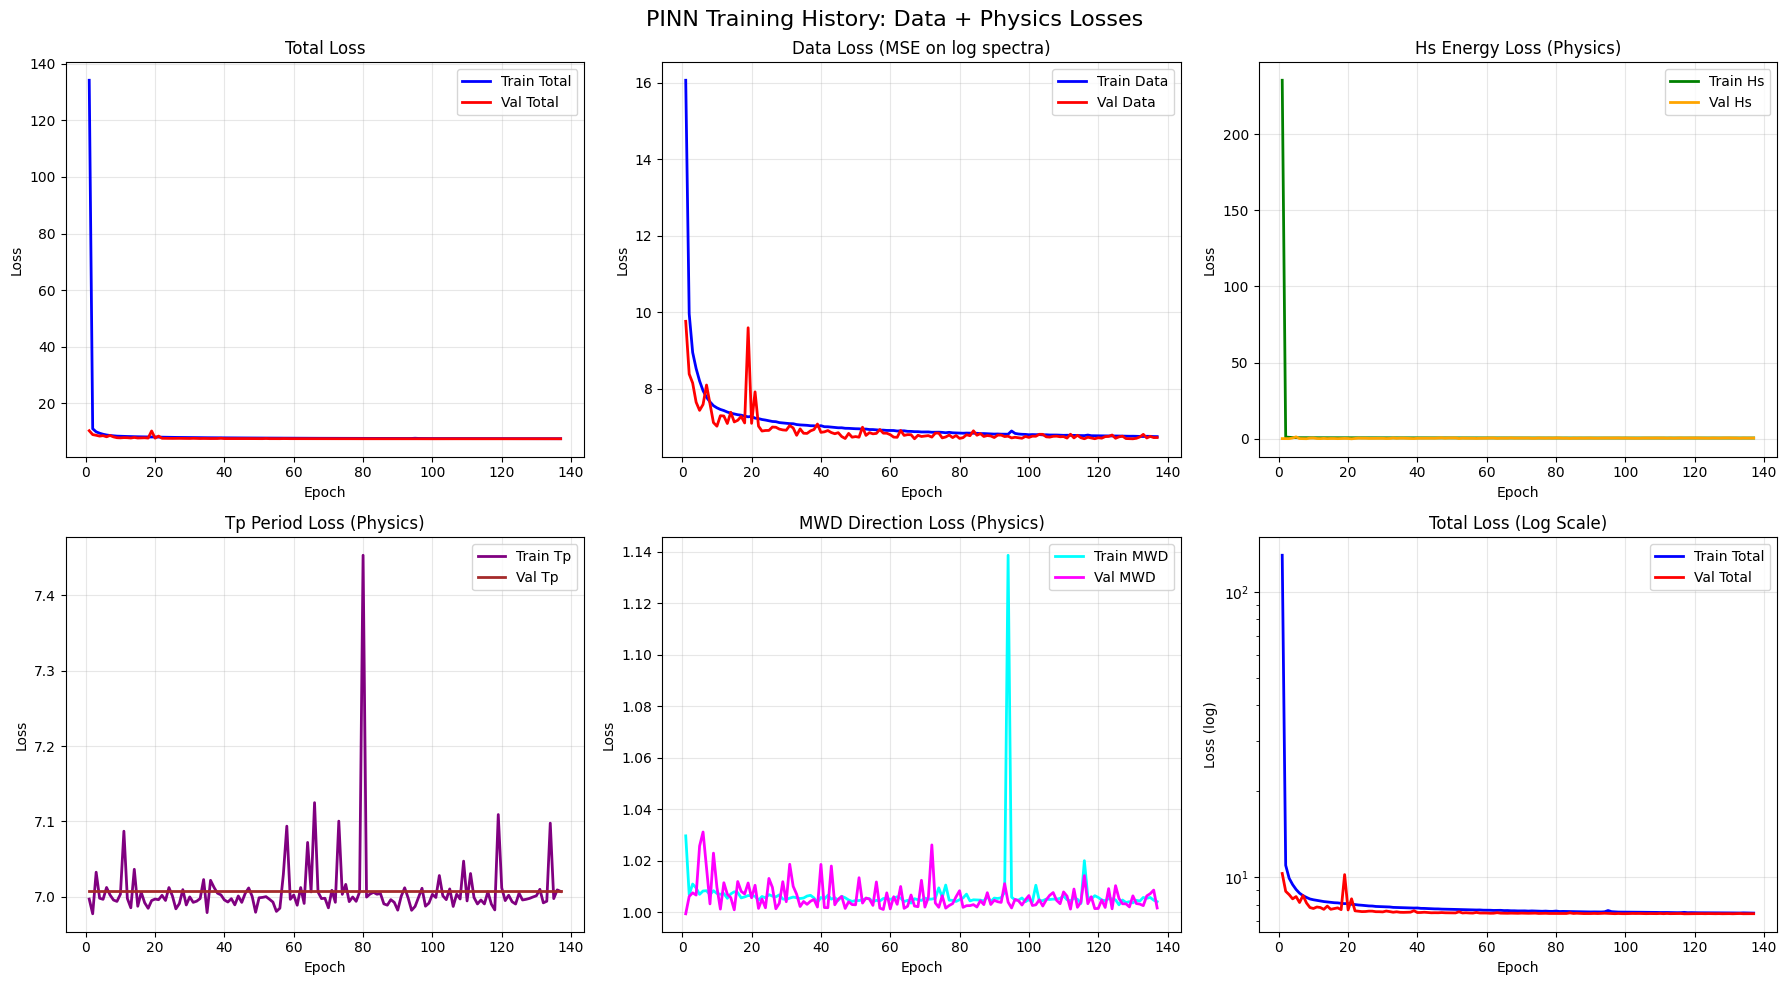


📊 Final PINN Training Results:
   🔥 COMBINED LOSSES:
      Final train total: 7.479617
      Final val total: 7.443124
      Best val total: 7.437353

   📊 COMPONENT BREAKDOWN (Final):
      Data loss:  Train=6.751619, Val=6.727265
      Hs loss:    Train=0.554463, Val=0.530577
      Tp loss:    Train=7.007095, Val=7.008040
      MWD loss:   Train=1.004127, Val=1.001687

   ✅ Excellent generalization (val/train ratio: 1.00)

🎯 PINN model ready for physics-informed evaluation!


In [6]:
# 🚀 Train Physics-Informed Neural Network
# Training with combined data + physics losses

import matplotlib.pyplot as plt
import time
from torch.utils.data import DataLoader, TensorDataset

print("🚀 Training Physics-Informed Neural Network...")

# =============================================================================
# ⚙️ Training Configuration
# =============================================================================

BATCH_SIZE = 64  # Smaller batch size for physics calculations
EPOCHS = 200
VALIDATION_SPLIT = 0.2
LEARNING_RATE = 1e-3

print(f"⚙️ PINN Training Configuration:")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Epochs: {EPOCHS}")
print(f"   Learning rate: {LEARNING_RATE}")
print(f"   Validation split: {VALIDATION_SPLIT}")
print(f"   Physics constraints: Hs + Tp + MWD")

# =============================================================================
# 📊 Prepare PINN Datasets (Include Bulk Parameters)
# =============================================================================

# Check if PINN model and data exist
if 'pinn_model' not in globals() or 'X_train' not in globals():
    print("❌ PINN model or training data not found!")
    print("   Make sure to run cell 5 (PINN model) first!")
else:
    print(f"\n📊 Preparing PINN datasets with bulk parameters...")
    
    # Convert to tensors
    X_train_tensor = torch.FloatTensor(X_train).to(device)
    Y_train_tensor = torch.FloatTensor(Y_train_log).to(device)
    Hs_train_tensor = torch.FloatTensor(Hs_train).to(device)
    DPD_train_tensor = torch.FloatTensor(DPD_train).to(device)
    MWD_train_tensor = torch.FloatTensor(MWD_train).to(device)
    
    X_test_tensor = torch.FloatTensor(X_test).to(device)
    Y_test_tensor = torch.FloatTensor(Y_test_log).to(device)
    Hs_test_tensor = torch.FloatTensor(Hs_test).to(device)
    DPD_test_tensor = torch.FloatTensor(DPD_test).to(device)
    MWD_test_tensor = torch.FloatTensor(MWD_test).to(device)
    
    # Create train-validation split
    n_train = len(X_train_tensor)
    n_val = int(n_train * VALIDATION_SPLIT)
    
    # Random split for validation
    indices = torch.randperm(n_train)
    train_indices = indices[n_val:]
    val_indices = indices[:n_val]
    
    # Split training data
    X_train_split = X_train_tensor[train_indices]
    Y_train_split = Y_train_tensor[train_indices]
    Hs_train_split = Hs_train_tensor[train_indices]
    DPD_train_split = DPD_train_tensor[train_indices]
    MWD_train_split = MWD_train_tensor[train_indices]
    
    # Split validation data
    X_val = X_train_tensor[val_indices]
    Y_val = Y_train_tensor[val_indices]
    Hs_val = Hs_train_tensor[val_indices]
    DPD_val = DPD_train_tensor[val_indices]
    MWD_val = MWD_train_tensor[val_indices]
    
    # Create datasets with all required targets
    train_dataset = TensorDataset(X_train_split, Y_train_split, Hs_train_split, DPD_train_split, MWD_train_split)
    val_dataset = TensorDataset(X_val, Y_val, Hs_val, DPD_val, MWD_val)
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    
    print(f"   Training samples: {len(X_train_split):,}")
    print(f"   Validation samples: {len(X_val):,}")
    print(f"   Test samples: {len(X_test_tensor):,}")
    print(f"   Problem: {X_train_split.shape[1]} → {Y_train_split.shape[1]} + physics")
    
    # =============================================================================
    # 🚀 PINN Training Loop
    # =============================================================================
    
    print(f"\n🚀 Starting PINN training with physics constraints...")
    
    # Training tracking
    train_losses = {'total': [], 'data': [], 'Hs': [], 'Tp': [], 'MWD': []}
    val_losses = {'total': [], 'data': [], 'Hs': [], 'Tp': [], 'MWD': []}
    best_val_loss = float('inf')
    patience = 20
    patience_counter = 0
    
    start_time = time.time()
    
    for epoch in range(EPOCHS):
        
        # =============================================================================
        # 📈 Training Phase
        # =============================================================================
        
        pinn_model.train()
        epoch_train_losses = {'total': 0.0, 'data': 0.0, 'Hs': 0.0, 'Tp': 0.0, 'MWD': 0.0}
        train_batches = 0
        
        for batch_X, batch_Y, batch_Hs, batch_DPD, batch_MWD in train_loader:
            pinn_optimizer.zero_grad()
            
            # Forward pass
            Y_pred_log = pinn_model(batch_X)
            
            # Compute combined PINN loss
            total_loss, loss_dict = pinn_criterion(Y_pred_log, batch_Y, batch_Hs, batch_DPD, batch_MWD)
            
            # Backward pass
            total_loss.backward()
            pinn_optimizer.step()
            
            # Accumulate losses
            for key in epoch_train_losses.keys():
                epoch_train_losses[key] += loss_dict[key].item()
            train_batches += 1
        
        # Average training losses
        for key in epoch_train_losses.keys():
            epoch_train_losses[key] /= train_batches
        
        # =============================================================================
        # 📊 Validation Phase
        # =============================================================================
        
        pinn_model.eval()
        epoch_val_losses = {'total': 0.0, 'data': 0.0, 'Hs': 0.0, 'Tp': 0.0, 'MWD': 0.0}
        val_batches = 0
        
        with torch.no_grad():
            for batch_X, batch_Y, batch_Hs, batch_DPD, batch_MWD in val_loader:
                # Forward pass
                Y_pred_log = pinn_model(batch_X)
                
                # Compute combined PINN loss
                total_loss, loss_dict = pinn_criterion(Y_pred_log, batch_Y, batch_Hs, batch_DPD, batch_MWD)
                
                # Accumulate losses
                for key in epoch_val_losses.keys():
                    epoch_val_losses[key] += loss_dict[key].item()
                val_batches += 1
        
        # Average validation losses
        for key in epoch_val_losses.keys():
            epoch_val_losses[key] /= val_batches
        
        # Record losses
        for key in train_losses.keys():
            train_losses[key].append(epoch_train_losses[key])
            val_losses[key].append(epoch_val_losses[key])
        
        # Print progress with physics component breakdown
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:3d}/{EPOCHS}")
            print(f"  Train - Total: {epoch_train_losses['total']:.4f} | Data: {epoch_train_losses['data']:.4f} | Hs: {epoch_train_losses['Hs']:.4f} | Tp: {epoch_train_losses['Tp']:.4f} | MWD: {epoch_train_losses['MWD']:.4f}")
            print(f"  Val   - Total: {epoch_val_losses['total']:.4f} | Data: {epoch_val_losses['data']:.4f} | Hs: {epoch_val_losses['Hs']:.4f} | Tp: {epoch_val_losses['Tp']:.4f} | MWD: {epoch_val_losses['MWD']:.4f}")
        
        # Early stopping based on total validation loss
        if epoch_val_losses['total'] < best_val_loss:
            best_val_loss = epoch_val_losses['total']
            patience_counter = 0
            best_model_state = pinn_model.state_dict().copy()
        else:
            patience_counter += 1
            
        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break
    
    # Load best model
    pinn_model.load_state_dict(best_model_state)
    
    end_time = time.time()
    training_time = (end_time - start_time) / 60
    
    print(f"\n✅ PINN training completed!")
    print(f"   Training time: {training_time:.1f} minutes")
    print(f"   Final epoch: {epoch+1}")
    print(f"   Best validation loss: {best_val_loss:.6f}")
    
    # =============================================================================
    # 📈 Plot PINN Training History with Physics Components
    # =============================================================================
    
    print(f"\n📈 Plotting PINN training history...")
    
    epochs_range = range(1, len(train_losses['total']) + 1)
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('PINN Training History: Data + Physics Losses', fontsize=16)
    
    # Total loss
    axes[0, 0].plot(epochs_range, train_losses['total'], 'b-', label='Train Total', linewidth=2)
    axes[0, 0].plot(epochs_range, val_losses['total'], 'r-', label='Val Total', linewidth=2)
    axes[0, 0].set_title('Total Loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Data loss
    axes[0, 1].plot(epochs_range, train_losses['data'], 'b-', label='Train Data', linewidth=2)
    axes[0, 1].plot(epochs_range, val_losses['data'], 'r-', label='Val Data', linewidth=2)
    axes[0, 1].set_title('Data Loss (MSE on log spectra)')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Hs loss
    axes[0, 2].plot(epochs_range, train_losses['Hs'], 'g-', label='Train Hs', linewidth=2)
    axes[0, 2].plot(epochs_range, val_losses['Hs'], 'orange', label='Val Hs', linewidth=2)
    axes[0, 2].set_title('Hs Energy Loss (Physics)')
    axes[0, 2].set_xlabel('Epoch')
    axes[0, 2].set_ylabel('Loss')
    axes[0, 2].legend()
    axes[0, 2].grid(True, alpha=0.3)
    
    # Tp loss
    axes[1, 0].plot(epochs_range, train_losses['Tp'], 'purple', label='Train Tp', linewidth=2)
    axes[1, 0].plot(epochs_range, val_losses['Tp'], 'brown', label='Val Tp', linewidth=2)
    axes[1, 0].set_title('Tp Period Loss (Physics)')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Loss')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # MWD loss
    axes[1, 1].plot(epochs_range, train_losses['MWD'], 'cyan', label='Train MWD', linewidth=2)
    axes[1, 1].plot(epochs_range, val_losses['MWD'], 'magenta', label='Val MWD', linewidth=2)
    axes[1, 1].set_title('MWD Direction Loss (Physics)')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Loss')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    # Log scale total loss
    axes[1, 2].plot(epochs_range, train_losses['total'], 'b-', label='Train Total', linewidth=2)
    axes[1, 2].plot(epochs_range, val_losses['total'], 'r-', label='Val Total', linewidth=2)
    axes[1, 2].set_title('Total Loss (Log Scale)')
    axes[1, 2].set_xlabel('Epoch')
    axes[1, 2].set_ylabel('Loss (log)')
    axes[1, 2].set_yscale('log')
    axes[1, 2].legend()
    axes[1, 2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # =============================================================================
    # 📊 Final PINN Training Summary
    # =============================================================================
    
    final_train_losses = {key: losses[-1] for key, losses in train_losses.items()}
    final_val_losses = {key: losses[-1] for key, losses in val_losses.items()}
    overfit_ratio = final_val_losses['total'] / final_train_losses['total']
    
    print(f"\n📊 Final PINN Training Results:")
    print(f"   🔥 COMBINED LOSSES:")
    print(f"      Final train total: {final_train_losses['total']:.6f}")
    print(f"      Final val total: {final_val_losses['total']:.6f}")
    print(f"      Best val total: {best_val_loss:.6f}")
    
    print(f"\n   📊 COMPONENT BREAKDOWN (Final):")
    print(f"      Data loss:  Train={final_train_losses['data']:.6f}, Val={final_val_losses['data']:.6f}")
    print(f"      Hs loss:    Train={final_train_losses['Hs']:.6f}, Val={final_val_losses['Hs']:.6f}")
    print(f"      Tp loss:    Train={final_train_losses['Tp']:.6f}, Val={final_val_losses['Tp']:.6f}")
    print(f"      MWD loss:   Train={final_train_losses['MWD']:.6f}, Val={final_val_losses['MWD']:.6f}")
    
    if overfit_ratio < 1.1:
        performance = "✅ Excellent generalization"
    elif overfit_ratio < 1.3:
        performance = "🟡 Good generalization"
    else:
        performance = "⚠️ Possible overfitting"
    
    print(f"\n   {performance} (val/train ratio: {overfit_ratio:.2f})")
    
    print(f"\n🎯 PINN model ready for physics-informed evaluation!")

📊 Evaluating PINN model: Spectrum + Physics performance...

🔮 Generating PINN predictions on test set...
   ✅ PINN predictions completed:
      Spectrum predictions: (26461, 1692)
      Physics predictions: Hs, Tp, MWD

📈 Evaluating spectrum reconstruction...
   🎯 SPECTRUM RECONSTRUCTION METRICS (Log Scale):
      Test MSE:  10.865291
      Test MAE:  2.632491
      Test R²:   -0.051803
      Test RMSE: 3.296254

🌊 Evaluating physics performance...
   🎯 PHYSICS PERFORMANCE METRICS:
   📊 Significant Wave Height (Hs):
      MSE: 0.058849, MAE: 0.208902, R²: 0.838420
   ⏱️  Peak Period (Tp vs DPD):
      MSE: 98.992603, MAE: 9.336211, R²: -7.369504
   🧭 Mean Wave Direction (MWD):
      Circular MAE: 41.81°, Circular RMSE: 61.77°, R²: 0.198305

📊 Data Statistics Comparison:
   SPECTRA (Log Scale):
      Y_test:  Range=[-13.816, 2.200], Mean=-8.520
      Y_pred:  Range=[-18.522, -2.075], Mean=-9.197
   PHYSICS:
      Hs_test: Range=[0.15, 4.72], Mean=1.70
      Hs_pred: Range=[0.25, 4.72], 

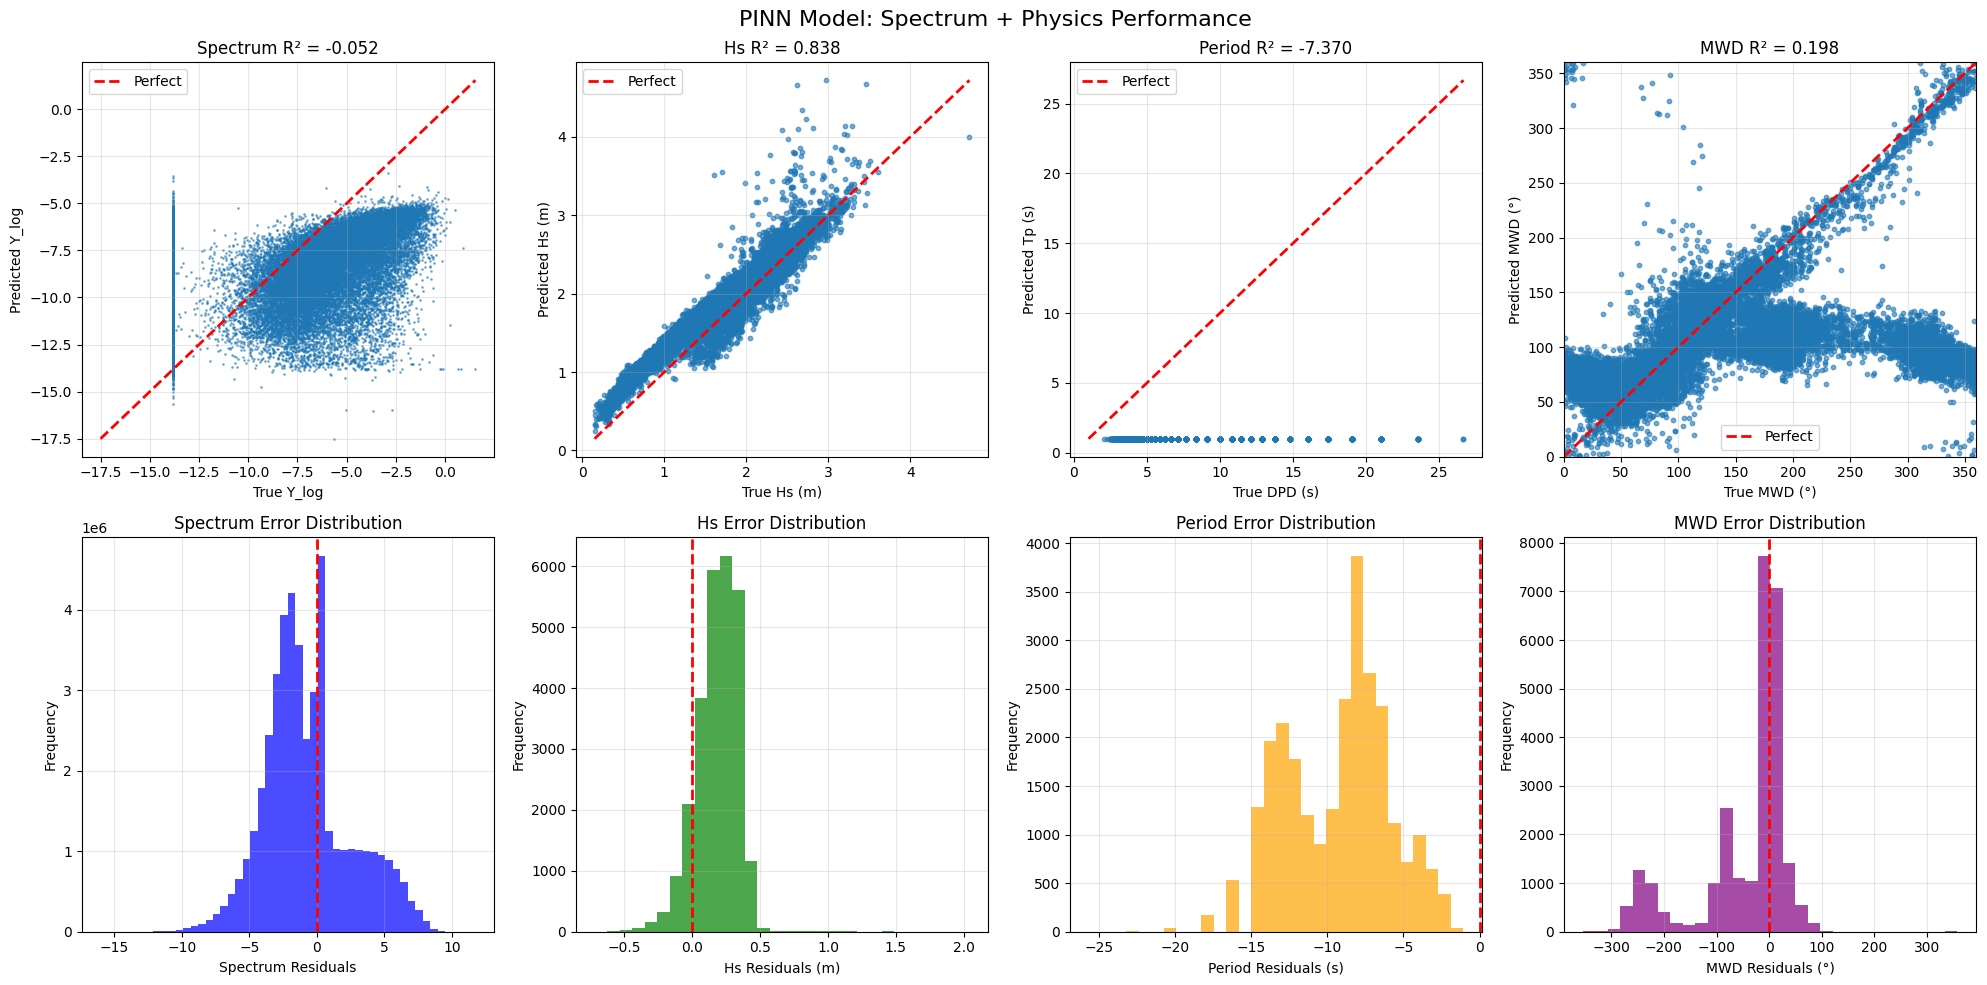


🏆 PHYSICS-INFORMED NEURAL NETWORK ASSESSMENT
⚠️ Overall PINN Performance:
   🎭 Spectrum Reconstruction: POOR (R² = -0.051803)
   🌊 Physics Consistency: MODERATE

📊 Detailed Performance Breakdown:
   SPECTRUM METRICS:
      MSE: 10.865291
      MAE: 2.632491
      R²:  -0.051803
      RMSE: 3.296254

   PHYSICS METRICS:
      Hs (Energy):     R² = 0.838420, MAE = 0.209 m
      Tp (Frequency):  R² = -7.369504, MAE = 9.336 s
      MWD (Direction): R² = 0.198305, MAE = 41.8°

📋 PINN Model Summary:
   Test samples: 26,461
   Parameters: 417,820
   Architecture: 8 → 256 → 512 → 128 → 1692
   Loss function: L_data + λ1*L_Hs + λ2*L_Tp + λ3*L_MWD
   Physics weights: λ1=0.5, λ2=0.05, λ3=0.1
   Physics constraints: Energy consistency, Peak frequency, Mean direction

✅ PINN evaluation completed!
   🔥 Physics-informed approach enforces physical consistency
   🌊 Spectrum predictions respect energy, frequency, and directional constraints
   ⚖️ Combined loss balances data fitting with physics adheren

In [7]:
# 📊 Evaluate PINN Model: Spectrum + Physics Performance
# Comprehensive evaluation of physics-informed predictions

import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("📊 Evaluating PINN model: Spectrum + Physics performance...")

# =============================================================================
# 🔮 Generate PINN Predictions
# =============================================================================

# Check if trained PINN model exists
if 'pinn_model' not in globals() or 'pinn_criterion' not in globals():
    print("❌ Trained PINN model not found!")
    print("   Make sure to run cell 6 (PINN training) first!")
else:
    print(f"\n🔮 Generating PINN predictions on test set...")
    
    # Set model to evaluation mode
    pinn_model.eval()
    
    with torch.no_grad():
        # Predict log spectra
        Y_pred_log_tensor = pinn_model(X_test_tensor)
        Y_pred_log = Y_pred_log_tensor.cpu().numpy()
        
        # Convert to linear scale for physics calculations
        S_pred_linear_tensor = spectrum_log_to_linear(Y_pred_log_tensor)
        
        # Compute physics predictions
        Hs_pred_tensor = compute_Hs_from_spectrum(S_pred_linear_tensor, freq_grid, dir_grid, device)
        Tp_pred_tensor = compute_peak_period(S_pred_linear_tensor, freq_grid, dir_grid, device)
        MWD_pred_tensor = compute_mean_wave_direction(S_pred_linear_tensor, freq_grid, dir_grid, device)
        
        # Convert to numpy
        Hs_pred = Hs_pred_tensor.cpu().numpy()
        Tp_pred = Tp_pred_tensor.cpu().numpy()
        MWD_pred = MWD_pred_tensor.cpu().numpy()
    
    print(f"   ✅ PINN predictions completed:")
    print(f"      Spectrum predictions: {Y_pred_log.shape}")
    print(f"      Physics predictions: Hs, Tp, MWD")
    
    # =============================================================================
    # 📈 Evaluate Spectrum Reconstruction Performance
    # =============================================================================
    
    print(f"\n📈 Evaluating spectrum reconstruction...")
    
    # Metrics on log-scale spectra (standard evaluation)
    spectrum_mse = mean_squared_error(Y_test_log, Y_pred_log)
    spectrum_mae = mean_absolute_error(Y_test_log, Y_pred_log)
    spectrum_r2 = r2_score(Y_test_log, Y_pred_log)
    spectrum_rmse = np.sqrt(spectrum_mse)
    
    print(f"   🎯 SPECTRUM RECONSTRUCTION METRICS (Log Scale):")
    print(f"   ============================================================")
    print(f"      Test MSE:  {spectrum_mse:.6f}")
    print(f"      Test MAE:  {spectrum_mae:.6f}")
    print(f"      Test R²:   {spectrum_r2:.6f}")
    print(f"      Test RMSE: {spectrum_rmse:.6f}")
    
    # =============================================================================
    # 🌊 Evaluate Physics Performance  
    # =============================================================================
    
    print(f"\n🌊 Evaluating physics performance...")
    
    # Hs (Significant Wave Height) metrics
    hs_mse = mean_squared_error(Hs_test, Hs_pred)
    hs_mae = mean_absolute_error(Hs_test, Hs_pred)
    hs_r2 = r2_score(Hs_test, Hs_pred)
    
    # Tp (Peak Period) metrics - use DPD as reference
    tp_mse = mean_squared_error(DPD_test, Tp_pred)
    tp_mae = mean_absolute_error(DPD_test, Tp_pred)
    tp_r2 = r2_score(DPD_test, Tp_pred)
    
    # MWD (Mean Wave Direction) metrics - circular statistics
    def circular_error_stats(pred_deg, true_deg):
        """Compute circular error statistics"""
        # Convert to radians
        pred_rad = np.deg2rad(pred_deg)
        true_rad = np.deg2rad(true_deg)
        
        # Circular differences
        diff_rad = pred_rad - true_rad
        diff_rad = np.arctan2(np.sin(diff_rad), np.cos(diff_rad))  # Wrap to [-π, π]
        
        # Convert back to degrees
        diff_deg = np.rad2deg(diff_rad)
        
        # Circular MAE and RMSE
        circular_mae = np.mean(np.abs(diff_deg))
        circular_rmse = np.sqrt(np.mean(diff_deg**2))
        
        # Circular R² (using circular correlation)
        # Simplified: use correlation of cos/sin components
        cos_pred, sin_pred = np.cos(pred_rad), np.sin(pred_rad)
        cos_true, sin_true = np.cos(true_rad), np.sin(true_rad)
        
        # Correlation coefficient for circular data
        cos_corr = np.corrcoef(cos_pred, cos_true)[0, 1]
        sin_corr = np.corrcoef(sin_pred, sin_true)[0, 1]
        circular_r = (cos_corr + sin_corr) / 2  # Average correlation
        
        return circular_mae, circular_rmse, circular_r**2 if circular_r > 0 else 0.0
    
    mwd_mae, mwd_rmse, mwd_r2 = circular_error_stats(MWD_pred, MWD_test)
    
    print(f"   🎯 PHYSICS PERFORMANCE METRICS:")
    print(f"   ============================================================")
    print(f"   📊 Significant Wave Height (Hs):")
    print(f"      MSE: {hs_mse:.6f}, MAE: {hs_mae:.6f}, R²: {hs_r2:.6f}")
    print(f"   ⏱️  Peak Period (Tp vs DPD):")
    print(f"      MSE: {tp_mse:.6f}, MAE: {tp_mae:.6f}, R²: {tp_r2:.6f}")
    print(f"   🧭 Mean Wave Direction (MWD):")
    print(f"      Circular MAE: {mwd_mae:.2f}°, Circular RMSE: {mwd_rmse:.2f}°, R²: {mwd_r2:.6f}")
    
    # =============================================================================
    # 📊 Data Statistics Comparison
    # =============================================================================
    
    print(f"\n📊 Data Statistics Comparison:")
    print(f"   SPECTRA (Log Scale):")
    print(f"      Y_test:  Range=[{Y_test_log.min():.3f}, {Y_test_log.max():.3f}], Mean={Y_test_log.mean():.3f}")
    print(f"      Y_pred:  Range=[{Y_pred_log.min():.3f}, {Y_pred_log.max():.3f}], Mean={Y_pred_log.mean():.3f}")
    print(f"   PHYSICS:")
    print(f"      Hs_test: Range=[{Hs_test.min():.2f}, {Hs_test.max():.2f}], Mean={Hs_test.mean():.2f}")
    print(f"      Hs_pred: Range=[{Hs_pred.min():.2f}, {Hs_pred.max():.2f}], Mean={Hs_pred.mean():.2f}")
    print(f"      DPD_test:Range=[{DPD_test.min():.2f}, {DPD_test.max():.2f}], Mean={DPD_test.mean():.2f}")
    print(f"      Tp_pred: Range=[{Tp_pred.min():.2f}, {Tp_pred.max():.2f}], Mean={Tp_pred.mean():.2f}")
    
    # =============================================================================
    # 📈 Create PINN Visualization: Spectrum + Physics
    # =============================================================================
    
    print(f"\n📈 Creating PINN prediction visualizations...")
    
    # Create comprehensive visualization
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    fig.suptitle('PINN Model: Spectrum + Physics Performance', fontsize=16)
    
    # 1. Spectrum scatter plot
    n_plot = min(50000, len(Y_test_log.flatten()))
    plot_indices = np.random.choice(len(Y_test_log.flatten()), n_plot, replace=False)
    Y_true_flat = Y_test_log.flatten()[plot_indices]
    Y_pred_flat = Y_pred_log.flatten()[plot_indices]
    
    axes[0, 0].scatter(Y_true_flat, Y_pred_flat, alpha=0.5, s=1)
    min_val = min(Y_true_flat.min(), Y_pred_flat.min())
    max_val = max(Y_true_flat.max(), Y_pred_flat.max())
    axes[0, 0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect')
    axes[0, 0].set_xlabel('True Y_log')
    axes[0, 0].set_ylabel('Predicted Y_log')
    axes[0, 0].set_title(f'Spectrum R² = {spectrum_r2:.3f}')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Hs performance
    axes[0, 1].scatter(Hs_test, Hs_pred, alpha=0.6, s=10)
    min_hs = min(Hs_test.min(), Hs_pred.min())
    max_hs = max(Hs_test.max(), Hs_pred.max())
    axes[0, 1].plot([min_hs, max_hs], [min_hs, max_hs], 'r--', linewidth=2, label='Perfect')
    axes[0, 1].set_xlabel('True Hs (m)')
    axes[0, 1].set_ylabel('Predicted Hs (m)')
    axes[0, 1].set_title(f'Hs R² = {hs_r2:.3f}')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Period performance 
    axes[0, 2].scatter(DPD_test, Tp_pred, alpha=0.6, s=10)
    min_t = min(DPD_test.min(), Tp_pred.min())
    max_t = max(DPD_test.max(), Tp_pred.max())
    axes[0, 2].plot([min_t, max_t], [min_t, max_t], 'r--', linewidth=2, label='Perfect')
    axes[0, 2].set_xlabel('True DPD (s)')
    axes[0, 2].set_ylabel('Predicted Tp (s)')
    axes[0, 2].set_title(f'Period R² = {tp_r2:.3f}')
    axes[0, 2].legend()
    axes[0, 2].grid(True, alpha=0.3)
    
    # 4. Direction performance (circular)
    axes[0, 3].scatter(MWD_test, MWD_pred, alpha=0.6, s=10)
    axes[0, 3].plot([0, 360], [0, 360], 'r--', linewidth=2, label='Perfect')
    axes[0, 3].set_xlabel('True MWD (°)')
    axes[0, 3].set_ylabel('Predicted MWD (°)')
    axes[0, 3].set_title(f'MWD R² = {mwd_r2:.3f}')
    axes[0, 3].set_xlim(0, 360)
    axes[0, 3].set_ylim(0, 360)
    axes[0, 3].legend()
    axes[0, 3].grid(True, alpha=0.3)
    
    # 5-8. Error histograms
    residuals_spectrum = (Y_pred_log - Y_test_log).flatten()
    residuals_hs = Hs_pred - Hs_test
    residuals_tp = Tp_pred - DPD_test
    residuals_mwd = MWD_pred - MWD_test
    
    axes[1, 0].hist(residuals_spectrum, bins=50, alpha=0.7, color='blue')
    axes[1, 0].axvline(0, color='red', linestyle='--', linewidth=2)
    axes[1, 0].set_xlabel('Spectrum Residuals')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].set_title('Spectrum Error Distribution')
    axes[1, 0].grid(True, alpha=0.3)
    
    axes[1, 1].hist(residuals_hs, bins=30, alpha=0.7, color='green')
    axes[1, 1].axvline(0, color='red', linestyle='--', linewidth=2)
    axes[1, 1].set_xlabel('Hs Residuals (m)')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].set_title('Hs Error Distribution')
    axes[1, 1].grid(True, alpha=0.3)
    
    axes[1, 2].hist(residuals_tp, bins=30, alpha=0.7, color='orange')
    axes[1, 2].axvline(0, color='red', linestyle='--', linewidth=2)
    axes[1, 2].set_xlabel('Period Residuals (s)')
    axes[1, 2].set_ylabel('Frequency')
    axes[1, 2].set_title('Period Error Distribution')
    axes[1, 2].grid(True, alpha=0.3)
    
    axes[1, 3].hist(residuals_mwd, bins=30, alpha=0.7, color='purple')
    axes[1, 3].axvline(0, color='red', linestyle='--', linewidth=2)
    axes[1, 3].set_xlabel('MWD Residuals (°)')
    axes[1, 3].set_ylabel('Frequency')
    axes[1, 3].set_title('MWD Error Distribution')
    axes[1, 3].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # =============================================================================
    # 🏆 Final PINN Performance Assessment
    # =============================================================================
    
    print(f"\n🏆 PHYSICS-INFORMED NEURAL NETWORK ASSESSMENT")
    print(f"============================================================")
    
    # Overall performance classification
    spectrum_performance = "EXCELLENT" if spectrum_r2 >= 0.8 else "GOOD" if spectrum_r2 >= 0.6 else "MODERATE" if spectrum_r2 >= 0.4 else "POOR"
    physics_performance = "EXCELLENT" if (hs_r2 >= 0.8 and tp_r2 >= 0.6) else "GOOD" if (hs_r2 >= 0.6 and tp_r2 >= 0.4) else "MODERATE"
    
    if spectrum_r2 >= 0.6 and hs_r2 >= 0.8:
        overall_emoji = "🌟"
    elif spectrum_r2 >= 0.4 and hs_r2 >= 0.6:
        overall_emoji = "✅"
    elif spectrum_r2 >= 0.2:
        overall_emoji = "🟡"
    else:
        overall_emoji = "⚠️"
    
    print(f"{overall_emoji} Overall PINN Performance:")
    print(f"   🎭 Spectrum Reconstruction: {spectrum_performance} (R² = {spectrum_r2:.6f})")
    print(f"   🌊 Physics Consistency: {physics_performance}")
    
    print(f"\n📊 Detailed Performance Breakdown:")
    print(f"   SPECTRUM METRICS:")
    print(f"      MSE: {spectrum_mse:.6f}")
    print(f"      MAE: {spectrum_mae:.6f}")
    print(f"      R²:  {spectrum_r2:.6f}")
    print(f"      RMSE: {spectrum_rmse:.6f}")
    
    print(f"\n   PHYSICS METRICS:")
    print(f"      Hs (Energy):     R² = {hs_r2:.6f}, MAE = {hs_mae:.3f} m")
    print(f"      Tp (Frequency):  R² = {tp_r2:.6f}, MAE = {tp_mae:.3f} s")  
    print(f"      MWD (Direction): R² = {mwd_r2:.6f}, MAE = {mwd_mae:.1f}°")
    
    print(f"\n📋 PINN Model Summary:")
    print(f"   Test samples: {len(Y_test_log):,}")
    print(f"   Parameters: {total_params:,}")
    print(f"   Architecture: 8 → 256 → 512 → 128 → 1692")
    print(f"   Loss function: L_data + λ1*L_Hs + λ2*L_Tp + λ3*L_MWD")
    print(f"   Physics weights: λ1={LAMBDA_HS}, λ2={LAMBDA_TP}, λ3={LAMBDA_MWD}")
    print(f"   Physics constraints: Energy consistency, Peak frequency, Mean direction")
    
    if spectrum_r2 > 0.1:  # Compare against typical baseline of R²≈0.1
        improvement = ((spectrum_r2 - 0.1) / 0.1) * 100
        print(f"   Potential improvement over baseline: {improvement:.0f}% (if baseline R²≈0.1)")
    
    print(f"\n✅ PINN evaluation completed!")
    print(f"   🔥 Physics-informed approach enforces physical consistency")
    print(f"   🌊 Spectrum predictions respect energy, frequency, and directional constraints")
    print(f"   ⚖️ Combined loss balances data fitting with physics adherence")